In [2]:
import sys
import os

# # Add the current file’s directory (or parent) to sys.path
# sys.path.append(os.path.dirname(os.path.abspath(__file__)))
# OR, if you’re in a Jupyter notebook:
# Go up two levels from the current working directory
parent_dir = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))

# Add that directory to Python's import path
sys.path.append(parent_dir)

In [3]:
import yaml
import torch
import sys, os

# Go to project root (two parents up from tests/)
project_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.append(project_root)

# Import
from src.blocks.SpectogramBlock import SpectrogramBlock


# Load YAML
with open("../../configs/spectogram.yaml", "r") as f:
    cfg = yaml.safe_load(f)

# Extract parameters
params = cfg["model"]["blocks"][0]["params"]

# Build the block
model = SpectrogramBlock(**params)




In [28]:
import torchaudio
import random
from pathlib import Path

# --- Load a random example audio file ---
examples_dir = Path("../../example").resolve()
wav_files = list(examples_dir.glob("*.wav"))
if not wav_files:
    raise FileNotFoundError(f"No .wav files found in {examples_dir}")

random_file = random.choice(wav_files)
print(f"🎵 Using random file: {random_file.name}")

waveform, sr = torchaudio.load(random_file)

🎵 Using random file: jazz_example.wav


In [29]:
# Run a test
x = waveform  # Add batch dimension: (1, 1, num_samples)
spec_dict = model(x)

print(spec_dict.keys())  # Should show the keys in the output dictionary

dict_keys(['freq_spec', 'time_spec', 'recon_spec', 'recon_wave'])


In [30]:
for key, value in spec_dict.items():
    print(f"{key}: {value.shape}")

freq_spec: torch.Size([1, 2, 2001, 201])
time_spec: torch.Size([1, 2, 501, 801])
recon_spec: torch.Size([1, 2, 1001, 401])
recon_wave: torch.Size([1, 240000])


In [43]:
import matplotlib.pyplot as plt
import torch

def visualize_spectrogram_parts(spectrogram, title="Spectrogram"):
    """
    Plots the real part, imaginary part, and log-magnitude of a (real, imag)-stacked spectrogram.
    Each is shown in its own figure.
    """
    # Handle both complex tensors and (real, imag)-stacked ones
    if spectrogram.ndim == 5:  # (B, 2, 1, F, T)
        spectrogram = spectrogram.squeeze(0).squeeze(1)  # → (2, F, T)
    elif spectrogram.ndim == 4:  # (B, 2, F, T)
        spectrogram = spectrogram.squeeze(0)  # → (2, F, T)

    if spectrogram.shape[0] != 2:
        raise ValueError("Expected spectrogram with shape (2, F, T) — real and imaginary stacked.")

    real_part = spectrogram[0].cpu().numpy()
    imag_part = spectrogram[1].cpu().numpy()
    log_mag = 10 * torch.log10((spectrogram[0]**2 + spectrogram[1]**2) + 1e-10)
    log_mag = log_mag.cpu().numpy()
    print("Log-mag shape:", log_mag.shape)

    # --- Real part ---
    plt.figure(figsize=(10, 4))
    plt.imshow(real_part, origin='lower', aspect='auto', cmap='coolwarm')
    plt.colorbar()
    plt.title(f"{title} - Real Part")
    plt.xlabel("Time Frames")
    plt.ylabel("Frequency Bins")
    plt.tight_layout()
    plt.show()

    # --- Imaginary part ---
    plt.figure(figsize=(10, 4))
    plt.imshow(imag_part, origin='lower', aspect='auto', cmap='coolwarm')
    plt.colorbar()
    plt.title(f"{title} - Imaginary Part")
    plt.xlabel("Time Frames")
    plt.ylabel("Frequency Bins")
    plt.tight_layout()
    plt.show()

    # --- Log-magnitude ---
    plt.figure(figsize=(10, 4))
    plt.imshow(log_mag, origin='lower', aspect='auto', cmap='magma')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"{title} - Log Magnitude")
    plt.xlabel("Time Frames")
    plt.ylabel("Frequency Bins")
    plt.tight_layout()
    plt.show()


Log-mag shape: (2001, 201)


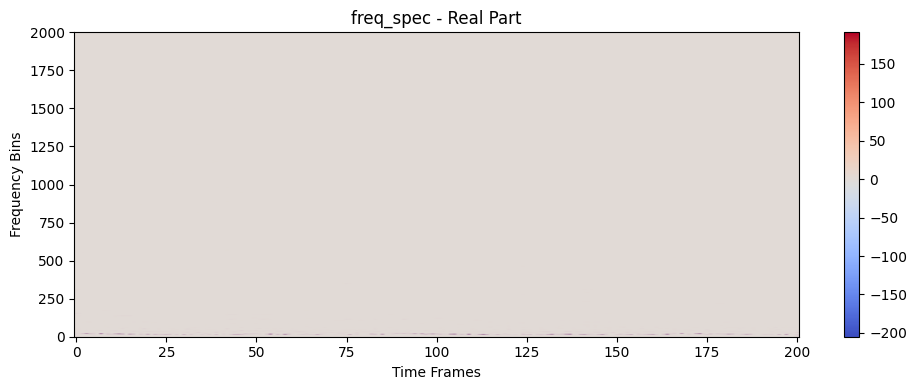

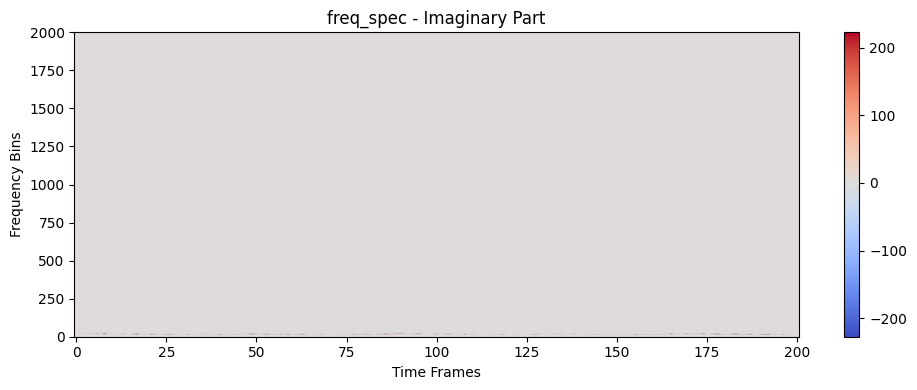

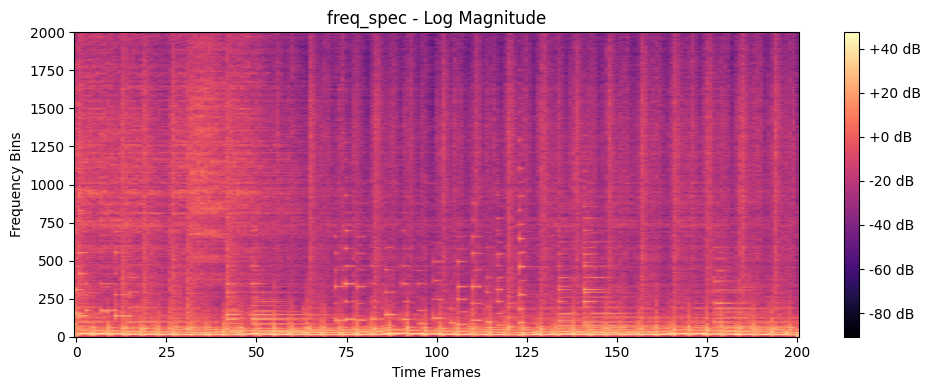

Log-mag shape: (501, 801)


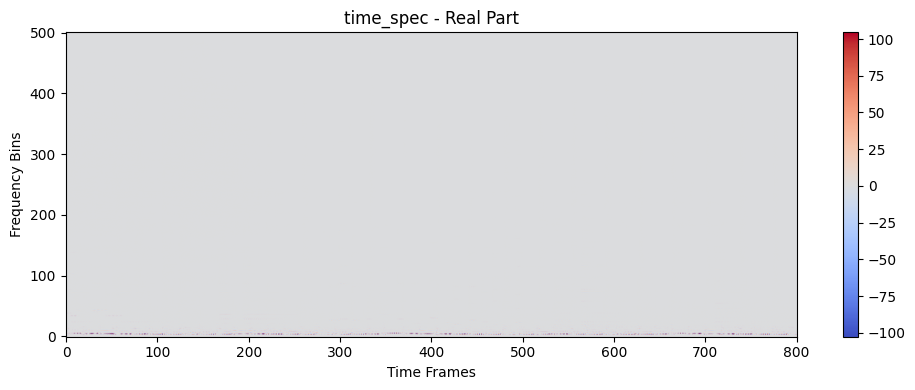

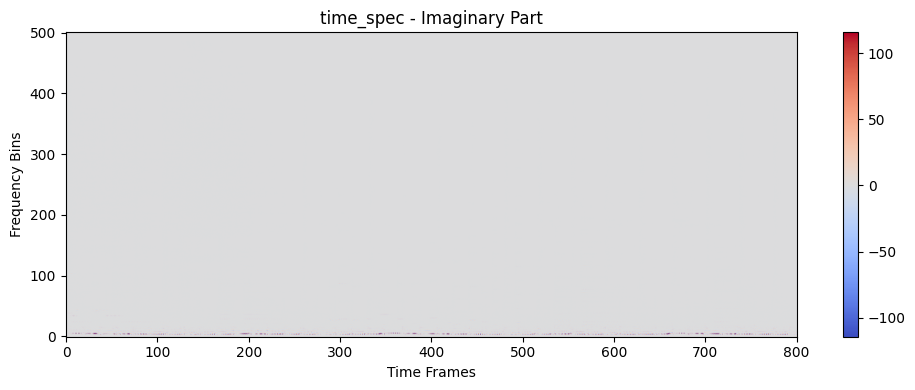

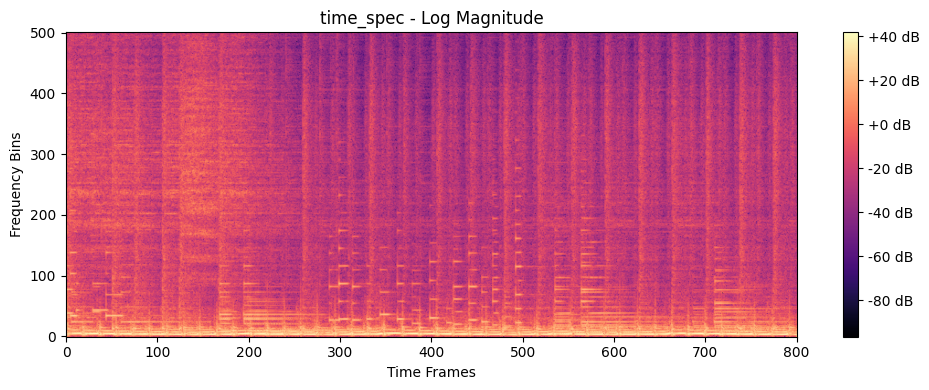

Log-mag shape: (1001, 401)


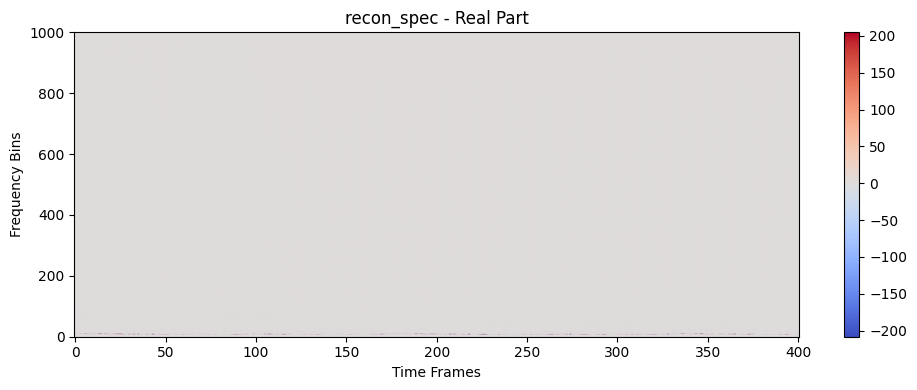

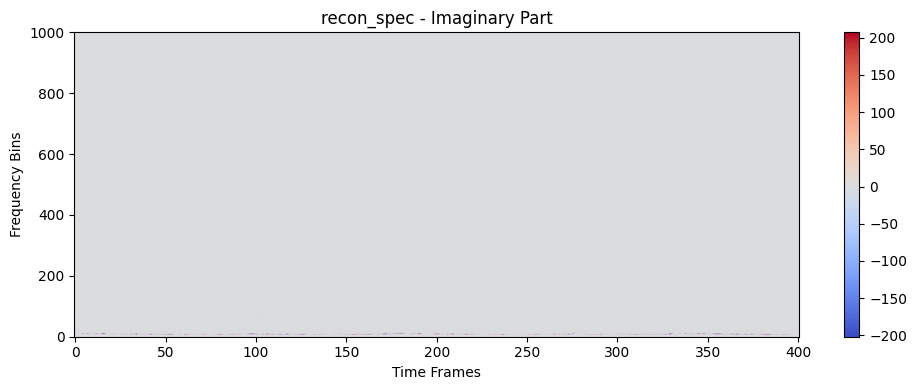

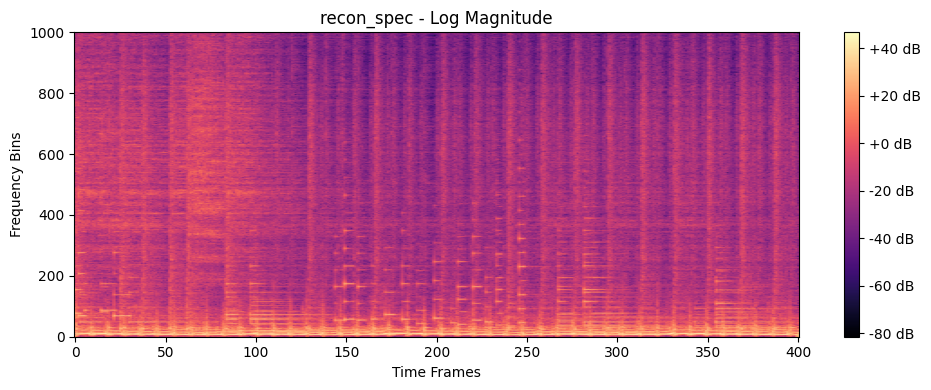

In [44]:

for key, value in spec_dict.items():
    if key == "recon_wave":  # skip waveform
        continue
    visualize_spectrogram_parts(value, title=key)



In [27]:
spec_dict['freq_spec']

tensor([[[[ 4.3796e+00,  5.2122e-01, -8.2790e-01,  ...,  1.6655e+00,
           -4.9078e+00,  5.7828e+00],
          [-3.8602e+00, -2.6161e-01,  7.8468e-01,  ..., -1.3965e+00,
            4.4934e+00, -5.3135e+00],
          [ 2.7339e+00, -3.8880e-01, -5.8318e-01,  ...,  8.9284e-01,
           -3.5730e+00,  4.1760e+00],
          ...,
          [-6.1885e-02, -3.2751e-04, -4.1482e-03,  ...,  3.6644e-03,
            5.5847e-03, -3.0344e-03],
          [ 5.9986e-02,  3.1590e-06,  7.8858e-03,  ..., -8.6001e-03,
           -7.8952e-03,  1.4663e-03],
          [-5.9142e-02,  2.3562e-04, -9.2164e-03,  ...,  1.0699e-02,
            8.8618e-03, -8.5020e-04]],

         [[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [-1.0101e-07,  5.5658e-02,  3.3963e-01,  ..., -2.6682e+00,
            1.5597e+00, -4.3352e-03],
          [ 6.0490e-07, -3.7099e-01, -6.1610e-01,  ...,  3.2563e+00,
           -1.9081e+00,  8.0720e-03],
          ...,
     

In [45]:
from src.blocks.InvSpecBlock import InvSpecBlock

invmodel = InvSpecBlock(**params)

TypeError: InvSpecBlock.__init__() got an unexpected keyword argument 'n_fft_f'